# Intro to Python, Part 2
## Namespace, functions, modules

# Functions

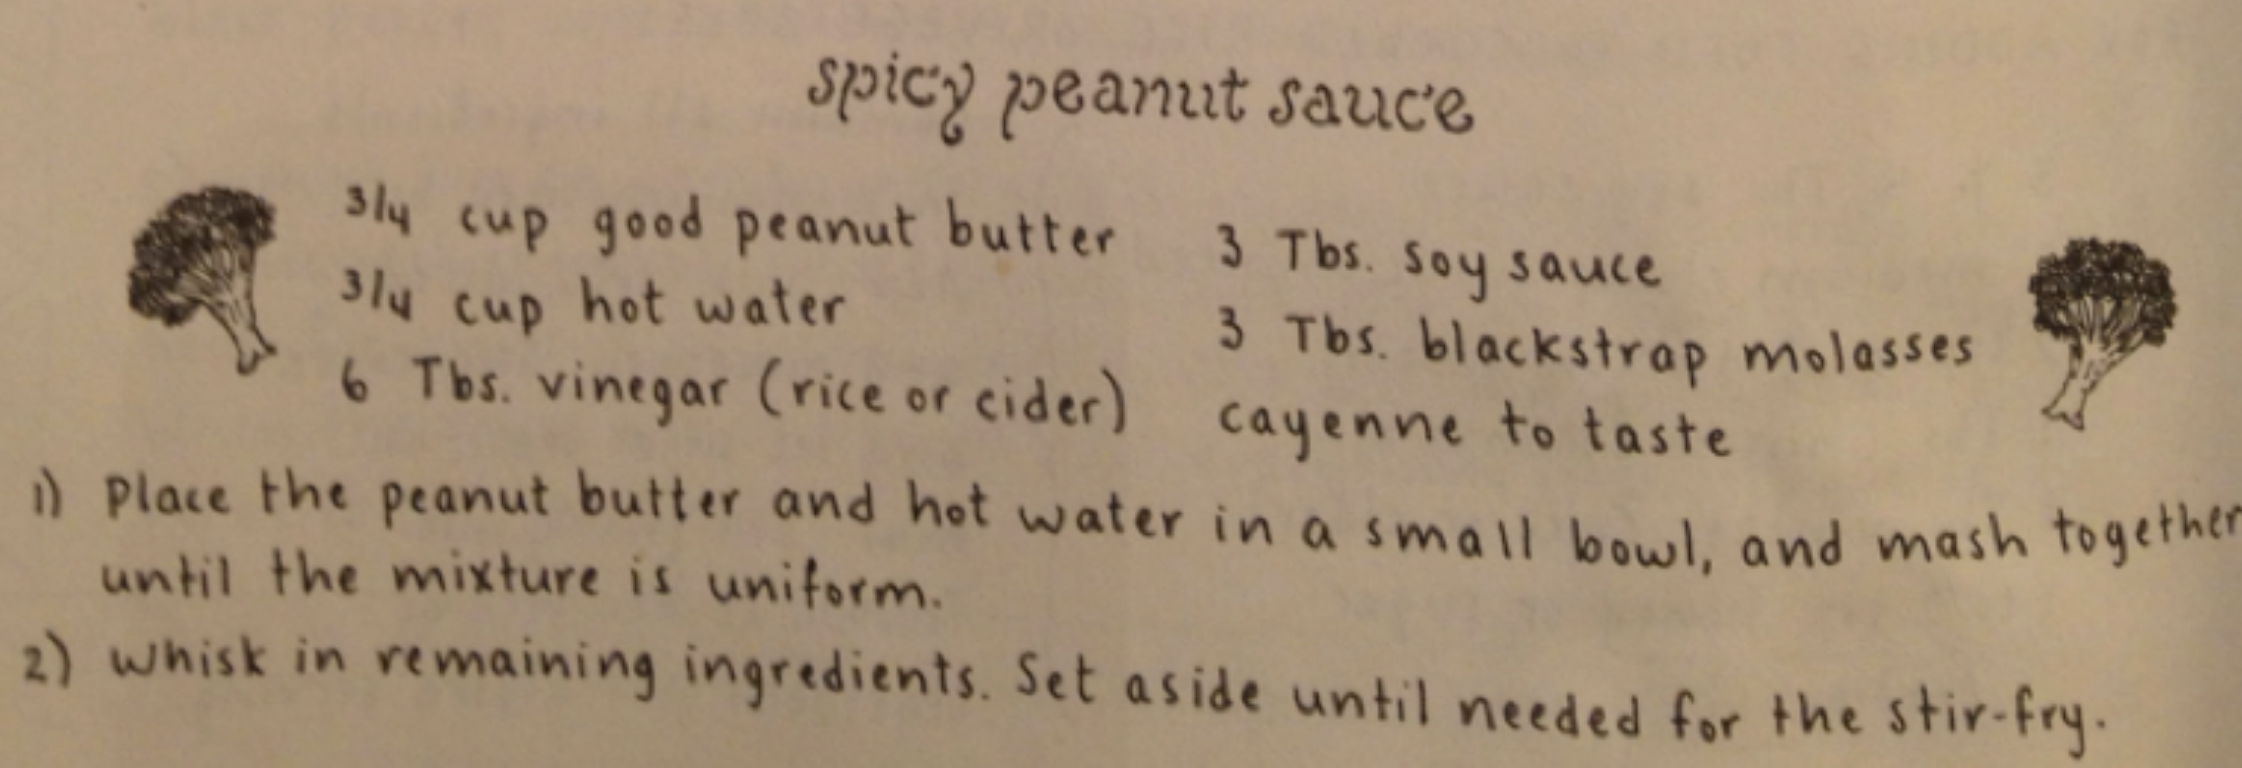

- A self-contained section of code
- Takes (zero or more) input parameters, does something, returns a value

# Predict what this code will print

In [9]:
def a_fxn(x):
    x = x + 5
    return x 

x = 2
a_fxn(x)
print(x)

2


In [7]:
def a_fxn(x):
    x = x + 5
    print(x)

x = 2
a_fxn(x)
print(x)

7
2


# Global vs local namespace

In [5]:
def a_fxn(x):
    x = x + 5      #This is local namespace (for x, just in this function)
    print("The local value of x is:", x)  #Local var can't be accessed outside the fxn

x = 2        #Here we are in global namespace (for x, in the entire script)
a_fxn(x)
print("The global value of x is:", x)

The local value of x is: 7
The global value of x is: 2


# Aside: visualizing Python

https://pythontutor.com/python-debugger.html

In [4]:
def a_fxn(x):
    x = x + 5
    print(x)

x = 2
a_fxn(x)
print(x)

7
2


# Defining functions

```python
def fxn_name(arguments):
    '''Doc string'''
    body of function
    return value
```

* Doc string and return statement optional. However, writing a doc string is good practice, ***so do it***
* Function will return ```None``` if ```return``` statement not found
* Functions can take one or more arguments
* The body of the function must be indented
* Functions must be defined before they are called
* The ```pass``` statement is useful while developing code

In [12]:
def a_new_fxn(x):
    pass       #remember to write this function!
    # Pass byasses the function so you don't get an error while working on your code

    
y = a_new_fxn(5)
print(y)

None


# Write some Python
Write a function that will take a string and return ```True``` if the string is a DNA sequence, returns ```False``` otherwise.

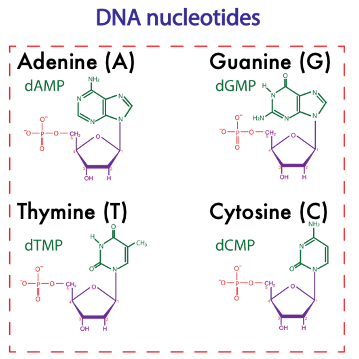

In [28]:
def validate_DNA_seq(DNA): 
    ''' This function takes a string. Returns True if string is composed of only As, Ts, Cs, and Gs. Otherwise returns false''' # Doc string
    
    # My attempt:
    # if "A" or "C" or "G" or "T" in DNA:
    #     if not ("A" or "C" or "G" or "T") in DNA:
    #         return False
    #     else: 
    #         return True

    # Shorter method without if statements
    DNA = DNA.upper()
    return DNA.count("A") + DNA.count("T") + DNA.count("C") + DNA.count("G") == len(DNA)

### Unit tests!!!
assert validate_DNA_seq("AATAGAT") == True, "DNA string not recognized"
print("Correctly identified a DNA string")
assert validate_DNA_seq("Hi there!") == False, "Non-DNA identified as DNA"
print("Correctly determined non-DNA")

Correctly identified a DNA string
Correctly determined non-DNA


# Hint: functions & methods we've seen so far
- `type()`
- `print()`
- `len()`
- `str.find()`
- `str.lower()` `str.upper()`
- `str.isupper()` `str.islower()`
- `str.count()`
- `str.find()`

In [30]:
help(validate_DNA_seq) # Gives you the doc string you wrote! Very helpful!

Help on function validate_DNA_seq in module __main__:

validate_DNA_seq(DNA)
    This function takes a string. Returns True if string is composed of only As, Ts, Cs, and Gs. Otherwise returns false



# Write some Python
Write a function that calculates the GC content of a DNA sequence

In [59]:
def gc_content(DNA):
    '''This function takes a DNA string and returns the percentage of the string that is Gs and Cs. Case insensitive'''
    assert validate_DNA_seq(DNA), "String contains invalid characters, this is not a DNA sequence"
    
    DNA = DNA.upper()
    GCs = DNA.count("G") + DNA.count("C")
    return GCs/len(DNA)

# Unit tests
assert gc_content("GCGCGC") == 1
assert gc_content("AATTATA") == 0
assert gc_content("GCATCGAT") == 0.5
print("correctly calculated GC content")

correctly calculated GC content


In [57]:
gc_content("TATTCGGA")

0.375

# What happens when we don't pass our function a DNA sequence?

In [58]:
gc_content("This is not a DNA sequence!")

0.037037037037037035

How can we improve our ```gc_content``` function?

In [60]:
gc_content("This is not a DNA sequence!")

AssertionError: String contains invalid characters, this is not a DNA sequence

# Using a flag to add functionality to a function
* Boolean value that determines which of two actions to perform
* Add a flag to `validate_DNA_seq` to create `validate_base_seq`
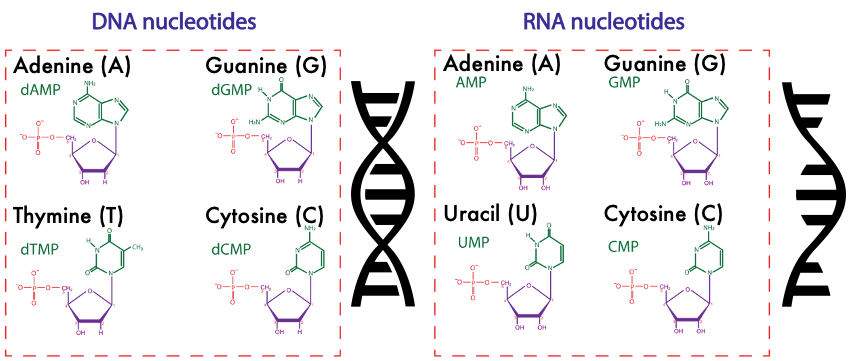

In [68]:
def validate_base_seq(seq, RNAflag):
    '''This function takes a string. Returns True if string is composed
    of only As, Ts, Gs, and Cs. False otherwise. Case insensitive.'''
    seq = seq.upper()
    return seq.count("A") + seq.count("U" if RNAflag else "T") + seq.count("C") + seq.count("G") == len(seq)
    
assert validate_base_seq("AATAGAT", False) == True, "Validate base seq does not work on DNA"
assert validate_base_seq("AAUAGAU", True) == True, "Validate base seq does not work on RNA"
assert validate_base_seq("TATUC",False) == False
assert validate_base_seq("UCUGCU", False) == False
print("Passed DNA and RNA tests")

Passed DNA and RNA tests


In [69]:
validate_base_seq("AATAGAT", False)

True

# Add a default value for a parameter

In [70]:
def validate_base_seq(seq: str, RNAflag: bool=False) -> bool:
    '''This function takes a string. Returns True if string is composed
    of only As, Ts (or Us if RNAflag), Gs, Cs. False otherwise. Case insensitive.'''
    seq = seq.upper()
    return seq.count("A") + seq.count("U" if RNAflag else "T") + seq.count("C") + seq.count("G") == len(seq)

assert validate_base_seq("AATAGAT") == True, "Validate base seq does not work on DNA"
assert validate_base_seq("AAUAGAU", True) == True, "Validate base seq does not work on RNA"
print("Passed DNA and RNA tests")

Passed DNA and RNA tests


In [71]:
print("testing RNA:")
assert validate_base_seq("AAUAGAU", True), "RNA test failed"
print("RNA test passed!")
print("testing DNA:")
assert validate_base_seq("AATAGAT"), "DNA test failed"
print("DNA test passed!")
print("testing non-nucleic acid:")
assert validate_base_seq("R is the best!")==False, "R sux"
print("non-nucleic test passsed!")

testing RNA:
RNA test passed!
testing DNA:
DNA test passed!
testing non-nucleic acid:
non-nucleic test passsed!


# Using modules
* Modules are (usually related) python code
* Can define
    * functions
    * classes
    * variables
* exmaple: math

In [72]:
sqrt(4)

NameError: name 'sqrt' is not defined

In [73]:
import math

In [74]:
math.sqrt(4)

2.0

In [75]:
help(math)

Help on module math:

NAME
    math

MODULE REFERENCE
    https://docs.python.org/3.14/library/math#module-math

    The following documentation is automatically generated from the Python
    source files.  It may be incomplete, incorrect or include features that
    are considered implementation detail and may vary between Python
    implementations.  When in doubt, consult the module reference at the
    location listed above.

DESCRIPTION
    This module provides access to the mathematical functions
    defined by the C standard.

FUNCTIONS
    acos(x, /)
        Return the arc cosine (measured in radians) of x.

        The result is between 0 and pi.

    acosh(x, /)
        Return the inverse hyperbolic cosine of x.

    asin(x, /)
        Return the arc sine (measured in radians) of x.

        The result is between -pi/2 and pi/2.

    asinh(x, /)
        Return the inverse hyperbolic sine of x.

    atan(x, /)
        Return the arc tangent (measured in radians) of x.

       

In [76]:
math.pi

3.141592653589793

# Selective import

In [77]:
from math import sqrt
sqrt(4)    #What happens if we "back up"?

2.0

In [78]:
from math import sqrt as SR
SR(4)

2.0

# ICA7 – Write a function to calculate the Pythagorean theorem
$$a^2 + b^2 = c^2$$
1. The function should take 2 parameters (a and b), compute the value of c and return it
2. Call your function with several different values for a and b and print the results
3. Check your work with a calculator
4. After writing your function in Jupyter Notebook, convert it to a .py file and execute it from the command line

In [93]:
def pythagorean(a: float,b: float) -> float:
    c = math.sqrt(a**2 + b**2)
    print(c)

In [94]:
pythag(3,4)
pythag(17,29)
pythag(100,100)

5.0
33.61547262794322
141.4213562373095
